In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dm=pd.read_csv(r"C:\Users\Maharshi Goswami\Downloads\dataminig\marketing_campaign.csv",sep='\t')

In [3]:
dm.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Cleaning

In [4]:
dm.isnull().sum()/len(dm)*100

ID                     0.000000
Year_Birth             0.000000
Education              0.000000
Marital_Status         0.000000
Income                 1.071429
Kidhome                0.000000
Teenhome               0.000000
Dt_Customer            0.000000
Recency                0.000000
MntWines               0.000000
MntFruits              0.000000
MntMeatProducts        0.000000
MntFishProducts        0.000000
MntSweetProducts       0.000000
MntGoldProds           0.000000
NumDealsPurchases      0.000000
NumWebPurchases        0.000000
NumCatalogPurchases    0.000000
NumStorePurchases      0.000000
NumWebVisitsMonth      0.000000
AcceptedCmp3           0.000000
AcceptedCmp4           0.000000
AcceptedCmp5           0.000000
AcceptedCmp1           0.000000
AcceptedCmp2           0.000000
Complain               0.000000
Z_CostContact          0.000000
Z_Revenue              0.000000
Response               0.000000
dtype: float64

In [5]:
# Income missing values
dm['Income'] = dm['Income'].fillna(dm['Income'].median())

### Total Spending features

In [6]:
# Missing values
print(dm.isnull().sum())



# Duplicates
dm.drop_duplicates(inplace=True)

# Total spending
dm['Total_Spending'] = (
    dm['MntWines'] +
    dm['MntFruits'] +
    dm['MntMeatProducts'] +
    dm['MntFishProducts'] +
    dm['MntSweetProducts'] +
    dm['MntGoldProds']
)

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


## Feature Selection

In [7]:
features = dm[[
    'Income',
    'Recency',
    'Total_Spending',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]]

## Feature Scaling

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(features)

## KMEANS APPLY

In [11]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
dm['Cluster'] = kmeans.fit_predict(X)
print(dm[['Cluster']].head())

   Cluster
0        3
1        2
2        1
3        2
4        0


In [12]:
print(dm['Cluster'].value_counts())

Cluster
1    583
2    576
3    542
0    539
Name: count, dtype: int64


In [13]:
cluster_summary = dm.groupby('Cluster')[[
    'Income',
    'Total_Spending',
    'Recency'
]].mean()

print(cluster_summary)

               Income  Total_Spending    Recency
Cluster                                         
0        37491.525974      135.428571  76.608534
1        60021.775300      764.591767  42.481990
2        34687.046007       97.753472  25.581597
3        77182.101476     1442.673432  53.894834


## EDA

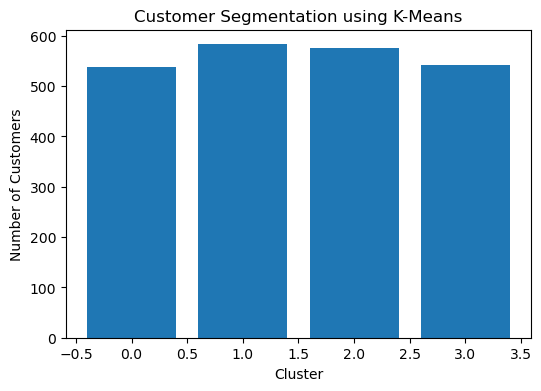

In [14]:
import matplotlib.pyplot as plt

cluster_counts = dm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Segmentation using K-Means')
plt.show()

#### K-Means clustering successfully divided customers into four meaningful groups, with each cluster containing a comparable number of customers. This indicates that the segmentation is balanced and suitable for targeted marketing strategies.

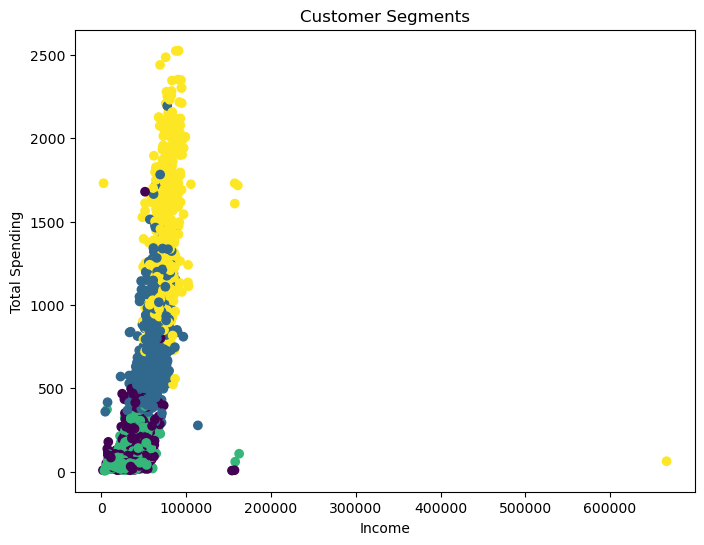

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    dm['Income'],
    dm['Total_Spending'],
    c=dm['Cluster']
)

plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.title('Customer Segments')
plt.show()

#### Customers with higher income tend to spend more on products, indicating a positive relationship between income and purchasing behavior.